In [372]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer


from torch.distributions.log_normal import LogNormal
from torch.distributions.normal import Normal

In [400]:
# dimension 1 = M_sat
num_dim = 2

# uniform distribution from 0.00001 ~ 1
prior_uniform = utils.BoxUniform(low = 0.00001 * torch.ones(num_dim), high = 1 * torch.ones(num_dim))

prior_normal = torch.distributions.MultivariateNormal(1 * torch.ones(num_dim), 0.1 * torch.eye(num_dim))


# print(prior_uniform.log_prob(0.1))
# print(prior_normal.log_prob(0.1))

tensor([1., 1.])


In [321]:
# lognormal distribution ~(0.01, 1)
# prior = LogNormal(torch.tensor([0.0]), torch.tensor([1.0]))

In [322]:
# # normal distribution ~(0.5, 0.1)
# prior = Normal(torch.tensor([0.5]), torch.tensor([0.1]))
# prior.log_prob(torch.tensor([0.1]))

In [323]:
# prior = torch.distributions.chi2.Chi2(torch.tensor([1.0]))

In [395]:
def simple_relation(phi1s, M_sat, scatter=0.5):

    phi2s=phi1s/M_sat

    positions = np.concatenate([phi1s,phi2s])
    positions = torch.from_numpy(positions)
    
    return positions + torch.randn_like(positions) * scatter

# print(simple_relation(np.arange(10), 0.1, 0.1))

tensor([1.7439e-01, 1.1650e+00, 1.8144e+00, 2.9834e+00, 3.9045e+00, 4.9369e+00,
        5.9407e+00, 7.1247e+00, 8.0300e+00, 9.0834e+00, 2.3813e-02, 1.0202e+01,
        1.9905e+01, 2.9950e+01, 3.9872e+01, 4.9821e+01, 6.0051e+01, 7.0018e+01,
        7.9947e+01, 8.9989e+01], dtype=torch.float64)


In [388]:
def simulator(params, n_obs=100, scatter=0.5):
    params=torch.as_tensor(params)
    M_sat=params[0]

    # phi1 values evenly spaced
    phi1s = np.arange(n_obs)

    return simple_relation(phi1s, M_sat, scatter)

In [391]:
# x = np.arange(100)
# y = simulator(torch.as_tensor([0.1]))

# plt.plot(x, y-x*10)

In [392]:
posterior = infer(simulator, prior_normal, "SNPE", num_simulations=1000)


Running 1000 simulations.: 100%|██████████| 1000/1000 [00:00<00:00, 9300.34it/s]


 Neural network successfully converged after 29 epochs.

In [328]:
# M_sat = [0.1]
observation1 = simulator(torch.as_tensor([0.1]))
# print(observation1.shape)

# M_sat = [0.9]
observation2= simulator(torch.as_tensor([0.9]))

# M_sat = [0.5]
observation3= simulator(torch.as_tensor([0.5]))

# M_sat = [0.3]
observation4 = simulator(torch.as_tensor([0.3]))

# M_sat = [0.7]
observation5 = simulator(torch.as_tensor([0.7]))

In [329]:
posterior_samples_1 = posterior.sample((10000,), x=observation1)

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 129332.88it/s]


In [330]:
posterior_samples_2 = posterior.sample((10000,), x=observation2)

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 142625.08it/s]


In [331]:
posterior_samples_3 = posterior.sample((10000,), x=observation3)

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 141049.49it/s]


In [332]:
posterior_samples_4 = posterior.sample((10000,), x=observation4)

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 141837.94it/s]


In [333]:
posterior_samples_5 = posterior.sample((10000,), x=observation5)

Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:00<00:00, 144732.49it/s]


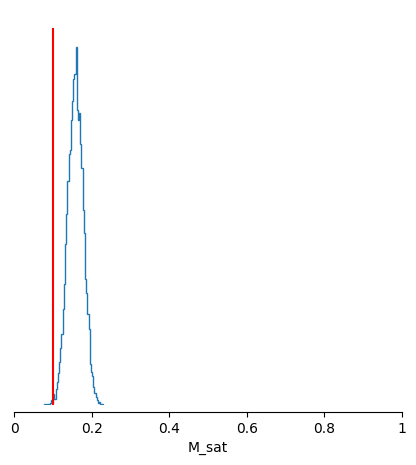

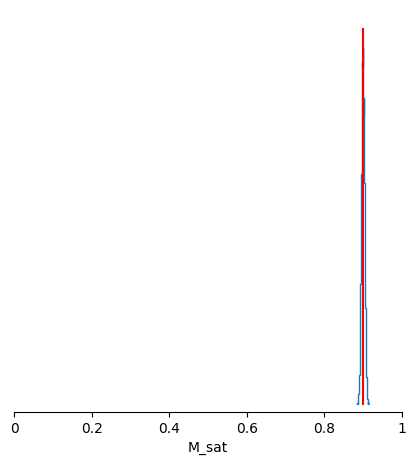

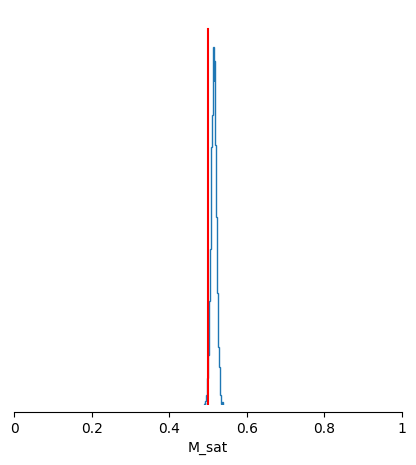

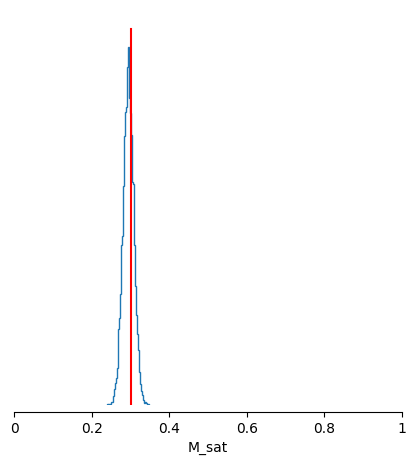

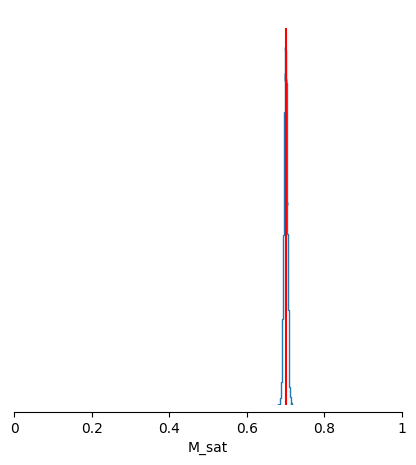

In [337]:
# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits = [[0,1]], figsize=(5, 5), labels=["M_sat"], points=[0.1],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_2, limits = [[0,1]], figsize=(5, 5), labels=["M_sat"], points=[0.9],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_3, limits = [[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.5],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_4, limits = [[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.3],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_5, limits = [[0,1]], figsize=(5, 5), labels = ["M_sat"], points=[0.7],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

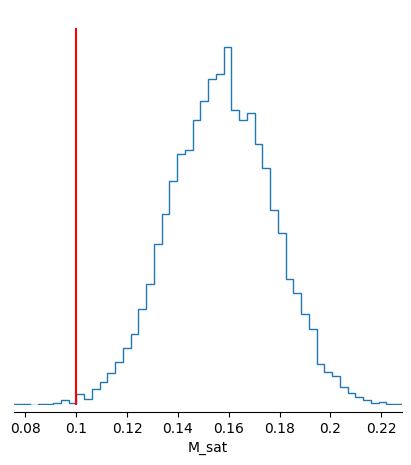

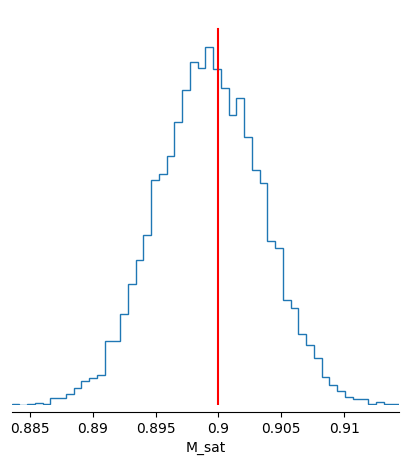

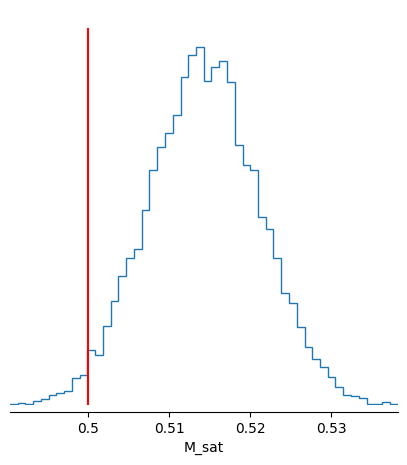

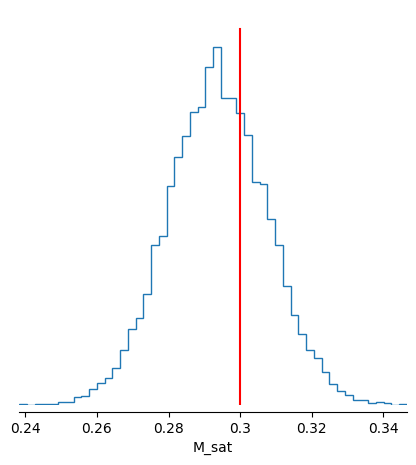

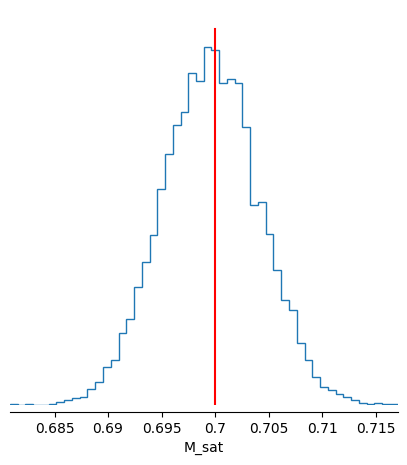

In [338]:
# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, figsize=(5, 5), labels=["M_sat"], points=[0.1],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_2, figsize=(5, 5), labels=["M_sat"], points=[0.9],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_3, figsize=(5, 5), labels = ["M_sat"], points=[0.5],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_4, figsize=(5, 5), labels = ["M_sat"], points=[0.3],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

_ = analysis.pairplot(
    posterior_samples_5, figsize=(5, 5), labels = ["M_sat"], points=[0.7],
    points_offdiag={"markersize": 6},
    points_colors="r",
)

with constant perturbation strength lines

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in true_divide


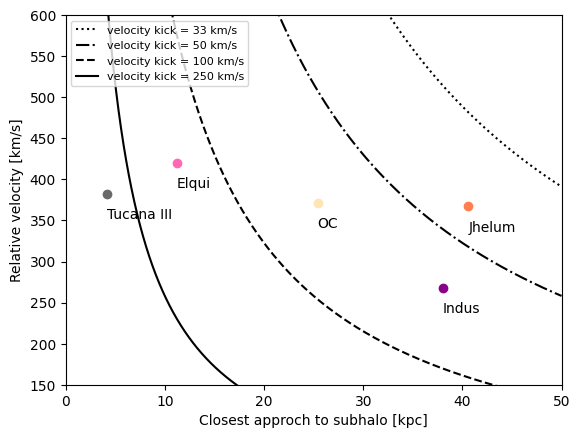

6.67e-11 2.985e+41 3.086e+20 33000.0


In [336]:
G=6.67e-11
M= 15 # mass of subhalo in 1e10 Msun
#b= impact parameter in kpc
#w= relative velocity in km/s

#delta_v in km/s
delta_v1= 33
delta_v2= 50
delta_v3= 100
delta_v4= 250

# x axis: cloest approach to subhalo, i.e. impact parameter b
# y axis: relative velocity at cloest approach, w


b = np.arange(0.0, 50.0, 0.01)
w1 = G*(M*1.99e40)/(b*3.086e19)/(delta_v1*1e3)/1e3
plt.plot(b,w1, label=f'velocity kick = {delta_v1} km/s', linestyle='dotted', color='black')


w2 = G*(M*1.99e40)/(b*3.086e19)/(delta_v2*1e3)/1e3
_ = plt.plot(b,w2, label=f'velocity kick = {delta_v2} km/s', linestyle='-.', color='black')

w3 = G*(M*1.99e40)/(b*3.086e19)/(delta_v3*1e3)/1e3
_ = plt.plot(b,w3, label=f'velocity kick = {delta_v3} km/s', linestyle='--', color='black')

w4 = G*(M*1.99e40)/(b*3.086e19)/(delta_v4*1e3)/1e3
_ = plt.plot(b,w4, label=f'velocity kick = {delta_v4} km/s', color='black')

plt.legend(prop={'size':8})
plt.xlim(0, 50)
plt.ylim(150, 600)
plt.xlabel("Closest approch to subhalo [kpc]")
plt.ylabel("Relative velocity [km/s]")


# stream models as dots
x=[4.2, 11.2, 25.4, 40.6, 38]
y=[382, 420, 371, 367, 268]
streams=['Tucana III', 'Elqui', 'OC', 'Jhelum', 'Indus']
colors=['dimgray', 'hotpink','moccasin','coral','darkmagenta']
for i in range(5):
    plt.plot(x[i],y[i],'o', color=colors[i])
    plt.text(x[i],y[i]-30, streams[i])

plt.show()
print(G, (M*1.99e40), (10*3.086e19), (delta_v1*1e3))